# IMPORT DATA

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [28]:
df= pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
counts=df['tenure'].value_counts().sort_index()
print(counts)

tenure
0      11
1     613
2     238
3     200
4     176
     ... 
68    100
69     95
70    119
71    170
72    362
Name: count, Length: 73, dtype: int64


In [33]:
counts.max()

613

In [34]:
df['tenure'].max()

72

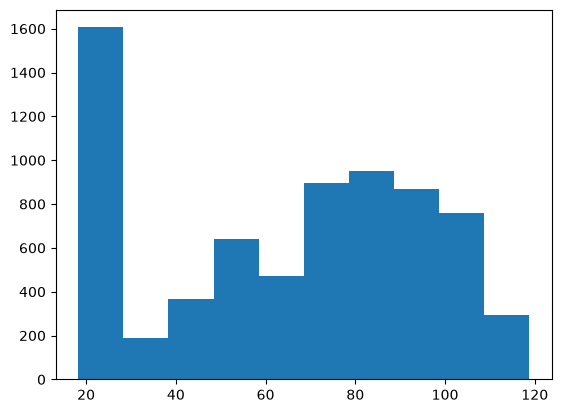

In [35]:
plt.hist(df['MonthlyCharges'])
plt.show()

In [36]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [37]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [38]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.groupby('Contract')['tenure'].agg(func='mean')

Contract
Month-to-month    18.036645
One year          42.044807
Two year          56.735103
Name: tenure, dtype: float64

In [40]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [41]:
df['TotalCharges'].dtypes

dtype('float64')

In [42]:
df.groupby('gender')['TotalCharges'].mean()

gender
Female    2283.190985
Male      2283.407861
Name: TotalCharges, dtype: float64

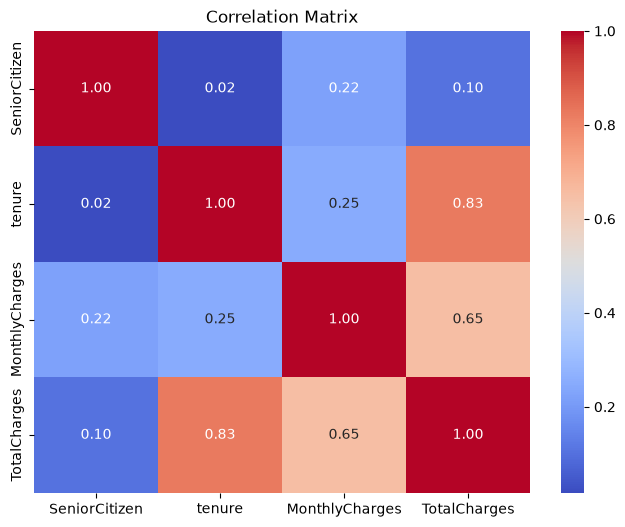

In [43]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


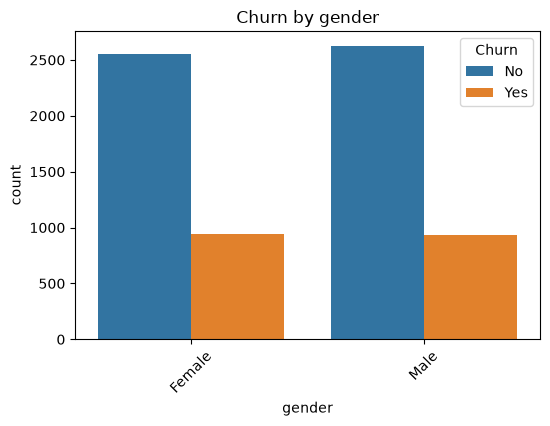

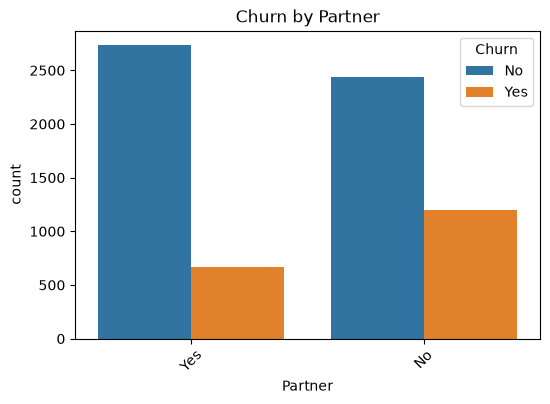

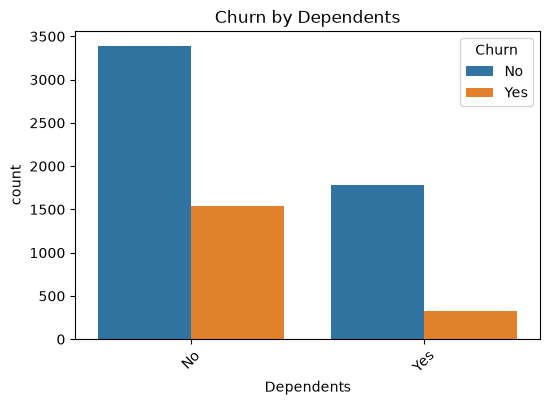

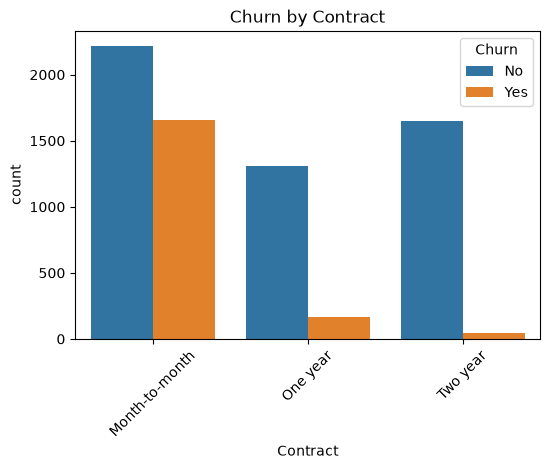

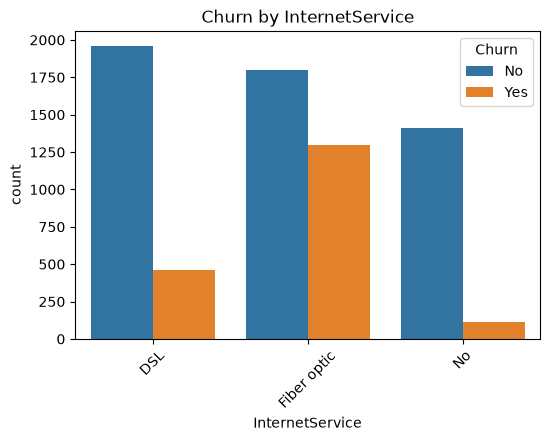

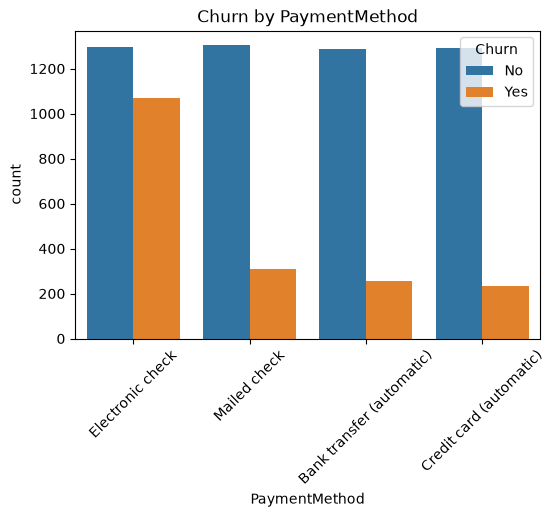

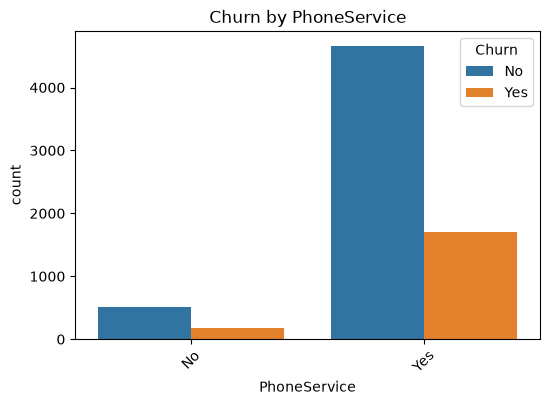

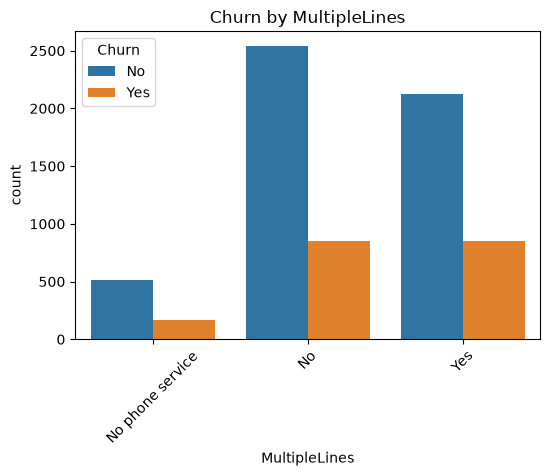

In [45]:
categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'Contract',
    'InternetService',
    'PaymentMethod',
    'PhoneService',
    'MultipleLines',
    
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.xticks(rotation=45)
    plt.title(f'Churn by {col}')
    plt.show()

In [46]:
df.drop(columns=['customerID', 'PhoneService','InternetService','OnlineSecurity','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling'],axis=1, inplace=True,errors='ignore')

In [47]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineBackup,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No phone service,Yes,Month-to-month,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,No,No,One year,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,No,Yes,Month-to-month,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No phone service,No,One year,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,No,No,Month-to-month,Electronic check,70.70,151.65,Yes


## FEATURE ENGINEERING

In [48]:
categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineBackup'
]


df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [49]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,OnlineBackup_No internet service,OnlineBackup_Yes
0,0,1,29.85,29.85,No,False,True,False,False,False,False,True,False,True,False,False,True
1,0,34,56.95,1889.50,No,True,False,False,True,False,False,False,True,False,False,False,False
2,0,2,53.85,108.15,Yes,True,False,False,False,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,No,True,False,False,True,False,False,False,False,True,False,False,False
4,0,2,70.70,151.65,Yes,False,False,False,False,False,False,True,False,False,False,False,False


In [50]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 16)
(1409, 16)
(5634,)
(1409,)


In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TRAINING AND TESTING MODELS

In [54]:
X.isnull().sum()[X.isnull().sum() > 0] # Foundout that they wher 11 values in TotalCharges showing NaN in the Table

TotalCharges    11
dtype: int64

In [55]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train) # For Logistic Regression 

LogisticRegression(max_iter=1000)

In [58]:
y_pred = model.predict(X_test_scaled)

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_imputed, y_train)

y_pred_rf = rf.predict(X_test_imputed) # For RandomForest

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



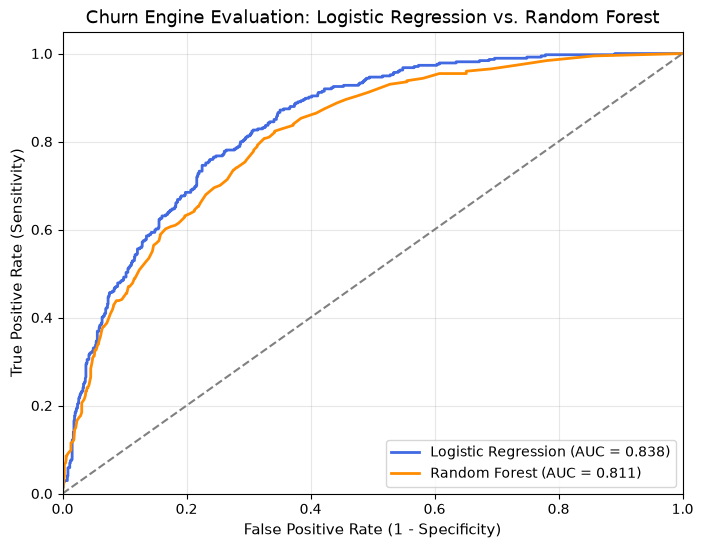

In [64]:
from sklearn.metrics import auc, roc_curve# 
1. Get predicted probabilities for both models
y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]  # Logistic Regression
y_prob_rf = rf.predict_proba(X_test_imputed)[:, 1]  # Random Forest

# 2. Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# 3. Build the plot
plt.figure(figsize=(8, 6))

# Logistic Regression Curve
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})',
    color='royalblue',
    lw=2,
)

# Random Forest Curve
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})',
    color='darkorange',
    lw=2,
)

# Random Guess Reference Line (AUC = 0.50)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')

# 4. Chart Labels and Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title(
    'Churn Engine Evaluation: Logistic Regression vs. Random Forest', fontsize=13
)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.show()

In [65]:
import joblib

# After training your scaler and model:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(model, 'logistic_regression_model.pkl')

['logistic_regression_model.pkl']

In [66]:
import joblib
import numpy as np
import pandas as pd


class LogisticChurnEngine:

  def __init__(self, model_path, scaler_path, feature_names):
    self.model = joblib.load(model_path)
    self.scaler = joblib.load(scaler_path)
    self.feature_names = feature_names

  def generate_report(self, raw_data_df):
    # 1. Scale incoming raw data using the training scaler
    scaled_data = self.scaler.transform(raw_data_df)

    # 2. Predict probabilities (Class 1 = Churn)
    churn_probs = self.model.predict_proba(scaled_data)[:, 1]

    # 3. Build results container
    results = raw_data_df.copy()
    results['churn_probability'] = churn_probs

    # 4. Assign business risk tiers
    results['risk_tier'] = pd.cut(
        results['churn_probability'],
        bins=[-np.inf, 0.3, 0.7, np.inf],
        labels=['Low Risk', 'Medium Risk', 'High Risk'],
    )

    # 5. High-level summary analytics
    summary = {
        'total_customers_evaluated': len(results),
        'high_risk_count': (results['risk_tier'] == 'High Risk').sum(),
        'average_churn_probability': float(np.mean(churn_probs)),
    }

    return results, summary

  def get_risk_drivers(self):
    # Extract model coefficients to show what pushes customers toward churn
    coefficients = pd.Series(
        self.model.coef_[0], index=self.feature_names
    ).sort_values(ascending=False)
    return coefficients